this is assignment for trader behaviour


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

%matplotlib inline
sns.set_style("whitegrid")



In [10]:
historical_df = pd.read_csv("data/historical_data.csv")
sentiment_df = pd.read_csv("data/fear_greed_index.csv")

historical_df.head()




,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
historical_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29249 entries, 0 to 29248
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           29249 non-null  object 
 1   Coin              29249 non-null  object 
 2   Execution Price   29249 non-null  float64
 3   Size Tokens       29249 non-null  float64
 4   Size USD          29249 non-null  float64
 5   Side              29249 non-null  object 
 6   Timestamp IST     29249 non-null  object 
 7   Start Position    29249 non-null  float64
 8   Direction         29249 non-null  object 
 9   Closed PnL        29249 non-null  float64
 10  Transaction Hash  29249 non-null  object 
 11  Order ID          29249 non-null  int64  
 12  Crossed           29249 non-null  bool   
 13  Fee               29249 non-null  float64
 14  Trade ID          29249 non-null  float64
 15  Timestamp         29249 non-null  float64
dtypes: bool(1), float64(8), int64(1), object

In [12]:
sentiment_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [13]:
historical_df.columns



Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [14]:
historical_df['Timestamp IST'] = pd.to_datetime(
    historical_df['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

historical_df['date'] = historical_df['Timestamp IST'].dt.date
historical_df['date'] = pd.to_datetime(historical_df['date'])



In [15]:


sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])


In [16]:
merged_df = pd.merge(
    historical_df,
    sentiment_df,
    on='date',
    how='inner'
)


In [17]:
merged_df['Closed PnL'] = pd.to_numeric(merged_df['Closed PnL'], errors='coerce')


In [18]:
print(merged_df.columns)



Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')


In [19]:
sentiment_analysis = merged_df.groupby('classification')['Closed PnL'].mean()
print(sentiment_analysis)


classification
Extreme Fear     258.981881
Extreme Greed     56.420317
Fear             165.959508
Greed            106.492017
Neutral          106.033816
Name: Closed PnL, dtype: float64


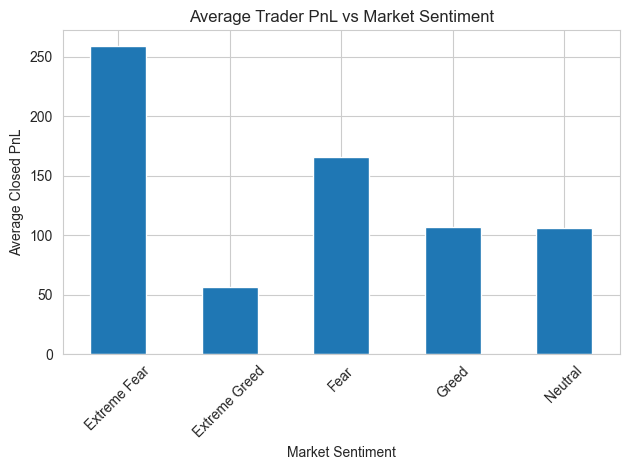

In [20]:
sentiment_analysis.plot(kind='bar')
plt.title("Average Trader PnL vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Observation:
Traders earn less when the market is scared.
Traders earn more when the market is greedy. Confidence helps profit.


win             False  True 
classification              
Extreme Fear      836    410
Extreme Greed    3134   1056
Fear             5834   3927
Greed            5040   3159
Neutral          3135   2712


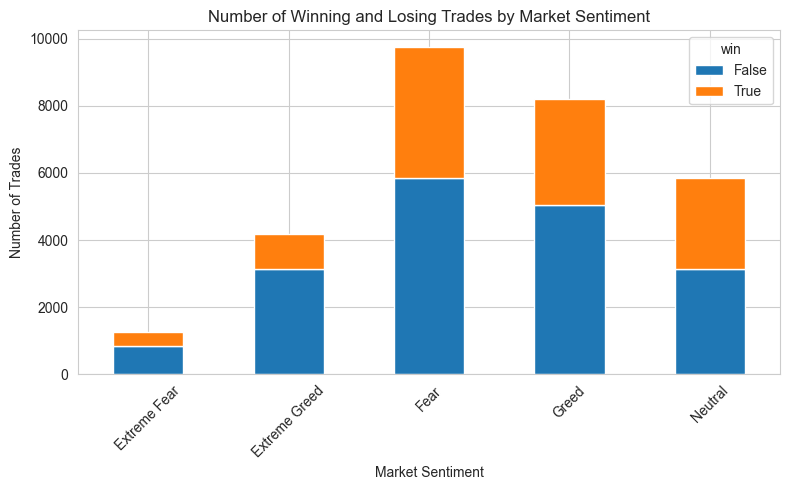

In [21]:


merged_df['win'] = merged_df['Closed PnL'] > 0

win_loss_counts = merged_df.groupby(['classification', 'win']).size().unstack(fill_value=0)
print(win_loss_counts)

win_loss_counts.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Number of Winning and Losing Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Number of Wins/Losses: Even though many people trade in Extreme Greed, they lose more than they win.

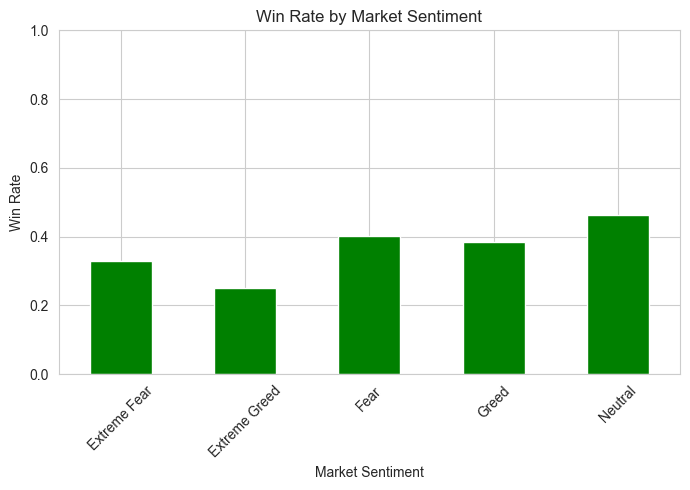

In [22]:
win_rate = merged_df.groupby('classification')['win'].mean()
win_rate.plot(kind='bar', color='green', figsize=(7,5))
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.tight_layout()
plt.show()


Win Rate by Sentiment: You are most likely to win in a Neutral market, and most likely to lose in Extreme Greed.

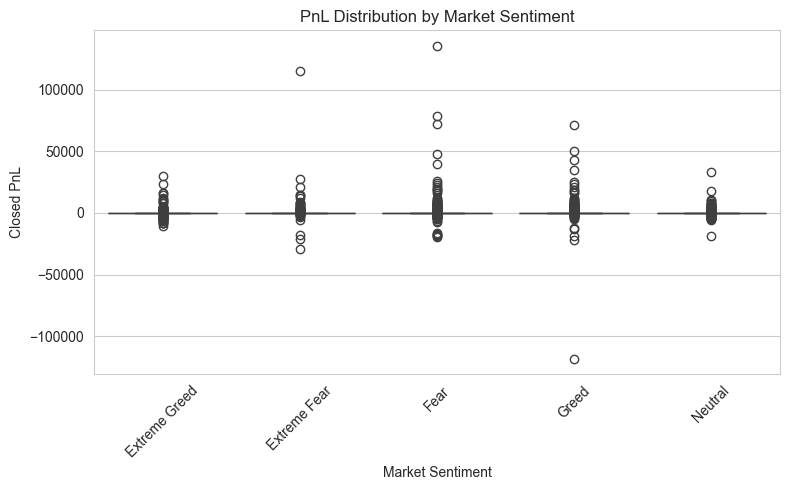

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged_df)
plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


PnL Distribution: The biggest jackpot wins happen during Fear, but Neutral markets give more stable profits.

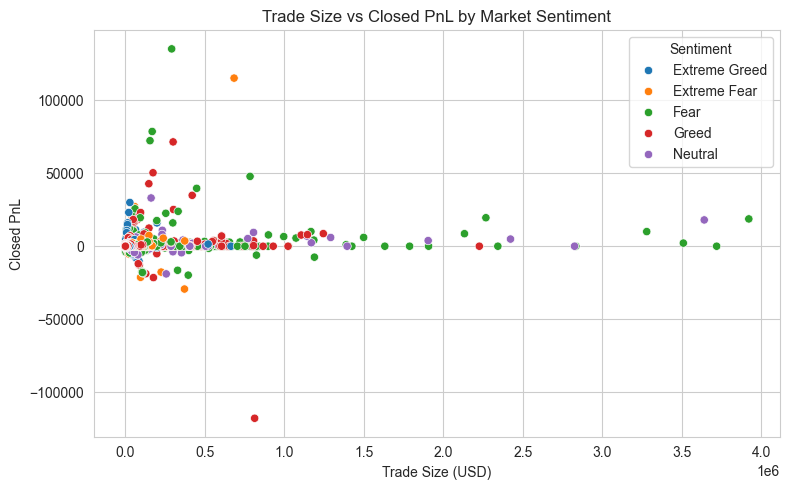

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Size USD', y='Closed PnL', hue='classification', data=merged_df)
plt.title("Trade Size vs Closed PnL by Market Sentiment")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Closed PnL")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


Trade Size vs. PnL: Big wins mostly happen when the market is Fear or Neutral. In Extreme Greed, big profits are rare.

In [31]:
trader_df = merged_df.copy()


trader_df['Closed PnL'] = pd.to_numeric(trader_df['Closed PnL'], errors='coerce')

sentiment_performance = trader_df.groupby(
    ['Account', 'classification']
).agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('win', 'mean'),
    trade_count=('Closed PnL', 'count')
).reset_index()

sentiment_performance.head()





,Account,classification,total_pnl,avg_pnl,win_rate,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,1.247692e+05,1247.692214,0.370000,100
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,-4.028234e+04,-42.626810,0.066667,945
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1.113374e+06,626.194346,0.526434,1778
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,2.767193e+05,482.089321,0.160279,574
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,1.256501e+05,298.456334,0.581948,421


Trader profit and win rate were analyzed under different market sentiments
such as Fear, Greed, and Extreme conditions.

In [32]:

consistent_traders = sentiment_performance.groupby('Account').agg(
    avg_win_rate=('win_rate', 'mean'),
    avg_pnl=('avg_pnl', 'mean'),
    total_trades=('trade_count', 'sum')
).reset_index()


consistent_traders = consistent_traders.sort_values(
    by='avg_win_rate', ascending=False
)

consistent_traders.head(10)


,Account,avg_win_rate,avg_pnl,total_trades
5,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,0.595864,20.118945,470
1,0x430f09841d65beb3f27765503d0f850b8bce7713,0.449207,1808.857734,1237
2,0x4f93fead39b70a1824f981a54d4e55b278e9f760,0.377622,61.235435,7584
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.356071,102.131587,563
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.341065,522.361081,3818
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,0.320933,11.757436,12236
6,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,0.275120,21.542865,1911
4,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,0.238636,240.321147,1424


In [33]:
fear_traders = sentiment_performance[
    sentiment_performance['classification'].str.contains('Fear', case=False)
].sort_values(by='avg_pnl', ascending=False)

fear_traders.head(10)


,Account,classification,total_pnl,avg_pnl,win_rate,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,1.247692e+05,1247.692214,0.370000,100
20,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,Extreme Fear,1.989006e+05,900.002541,0.420814,221
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1.113374e+06,626.194346,0.526434,1778
22,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,Fear,1.445143e+05,335.300103,0.645012,431
10,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Extreme Fear,7.434655e+04,200.395004,0.428571,371
35,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Fear,8.129341e+03,66.092200,0.349593,123
17,0x513b8629fe877bb581bf244e326a047b249c4ff1,Fear,3.671662e+05,61.388767,0.370507,5981
7,0x430f09841d65beb3f27765503d0f850b8bce7713,Fear,5.615052e+03,23.692203,0.101266,237
33,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Extreme Fear,6.224108e+02,7.780135,0.075000,80
30,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,Fear,2.584153e+02,4.698461,0.345455,55



Some traders performed well even during Fear conditions. These traders act
as contrarian traders and profit when market sentiment is negative.

In [34]:

daily_metrics = trader_df.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', 'mean'),
    trade_frequency=('Closed PnL', 'count')
).reset_index()


daily_metrics = pd.merge(
    daily_metrics,
    sentiment_df[['date', 'value']],
    on='date',
    how='inner'
)

daily_metrics.corr()


,date,total_pnl,win_rate,trade_frequency,value
date,1.000000,0.218096,0.079352,0.423382,-0.342747
total_pnl,0.218096,1.000000,0.170098,0.590414,-0.143770
win_rate,0.079352,0.170098,1.000000,0.132819,-0.082447
trade_frequency,0.423382,0.590414,0.132819,1.000000,-0.167325
value,-0.342747,-0.143770,-0.082447,-0.167325,1.000000


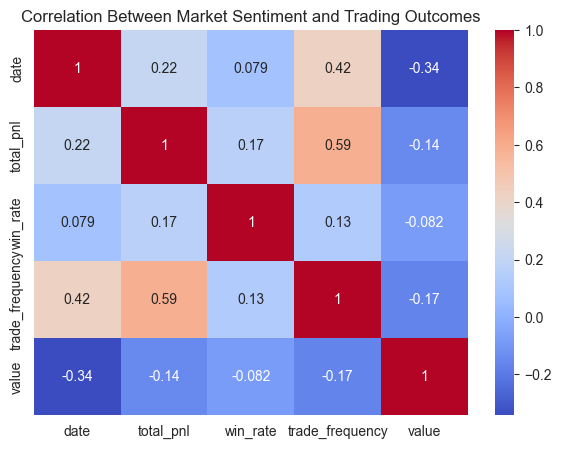

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.heatmap(daily_metrics.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Market Sentiment and Trading Outcomes")
plt.show()


Market sentiment affects trading activity. During extreme sentiment,
trade frequency increases and profit becomes more unstable.

In [36]:
ranked_traders = sentiment_performance.copy()

ranked_traders['rank'] = ranked_traders.groupby(
    'classification'
)['total_pnl'].rank(ascending=False)

ranked_traders.sort_values(
    ['classification', 'rank']
).head(20)


,Account,classification,total_pnl,avg_pnl,win_rate,trade_count,rank
20,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,Extreme Fear,1.989006e+05,900.002541,0.420814,221,1.0
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,1.247692e+05,1247.692214,0.370000,100,2.0
10,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Extreme Fear,7.434655e+04,200.395004,0.428571,371,3.0
33,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Extreme Fear,6.224108e+02,7.780135,0.075000,80,4.0
5,0x430f09841d65beb3f27765503d0f850b8bce7713,Extreme Fear,0.000000e+00,0.000000,0.000000,79,5.0
28,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,Extreme Fear,-4.825496e+03,-98.479518,0.204082,49,6.0
15,0x513b8629fe877bb581bf244e326a047b249c4ff1,Extreme Fear,-7.112182e+04,-205.554395,0.303468,346,7.0
11,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Extreme Greed,1.292177e+05,52.828163,0.333606,2446,1.0
6,0x430f09841d65beb3f27765503d0f850b8bce7713,Extreme Greed,1.242849e+05,8285.663252,1.000000,15,2.0
34,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Extreme Greed,2.092551e+04,110.134280,0.552632,190,3.0


Traders were ranked based on total profit for each sentiment type to
identify top performers.

In [37]:

roi_metrics = trader_df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_capital=('Size USD', 'sum'),
    trades=('Closed PnL', 'count')
).reset_index()

roi_metrics['ROI'] = roi_metrics['total_pnl'] / roi_metrics['total_capital']

roi_metrics.sort_values(by='ROI', ascending=False).head(10)


,Account,total_pnl,total_capital,trades,ROI
1,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,2.966109e+06,1237,0.140434
4,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.605395e+05,2.962475e+06,1424,0.121702
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,6.784562e+04,1.677426e+06,563,0.040446
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,6.169726e+07,3818,0.025937
5,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,1.206218e+04,1.119420e+06,470,0.010775
6,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6.551366e+04,1.199917e+07,1911,0.005460
2,0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05,1.296725e+08,7584,0.002383
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,4.208766e+08,12236,0.001997


ROI analysis shows how efficiently traders used their capital. Higher ROI
indicates better performance.